In [16]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

X_train = np.load('../data/processed/X_train.npy')
X_val = np.load('../data/processed/X_val.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val = np.load('../data/processed/y_val.npy')
y_test = np.load('../data/processed/y_test.npy')

max_words = 10000  
max_len = 300      
embedding_dim = 128

model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    LSTM(64, return_sequences=False),
    Dropout(0.5),  
    Dense(16, activation='relu'),
    Dropout(0.3),  
    Dense(1, activation='sigmoid')  
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

import os
os.makedirs('../models', exist_ok=True)
model.save('../models/modelo_fake_news.keras')
print(" Modelo salvo com sucesso em 'models/modelo_fake_news.keras'!")

C:\Users\yasmi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 26s 251ms/step - accuracy: 0.9095 - loss: 0.3477 - val_accuracy: 0.9102 - val_loss: 0.2838
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 218ms/step - accuracy: 0.9190 - loss: 0.2814 - val_accuracy: 0.9102 - val_loss: 0.2800
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 196ms/step - accuracy: 0.9204 - loss: 0.2711 - val_accuracy: 0.9148 - val_loss: 0.2709
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 193ms/step - accuracy: 0.9254 - loss: 0.2443 - val_accuracy: 0.9176 - val_loss: 0.2981
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 16s 204ms/step - accuracy: 0.9258 - loss: 0.2587 - val_accuracy: 0.9102 - val_loss: 0.2798
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 247ms/step - accuracy: 0.9284 - loss: 0.2281 - val_accuracy: 0.9167 - val_loss: 0.2882
 Modelo salvo com sucesso em 'models/modelo_fake_news.keras'!


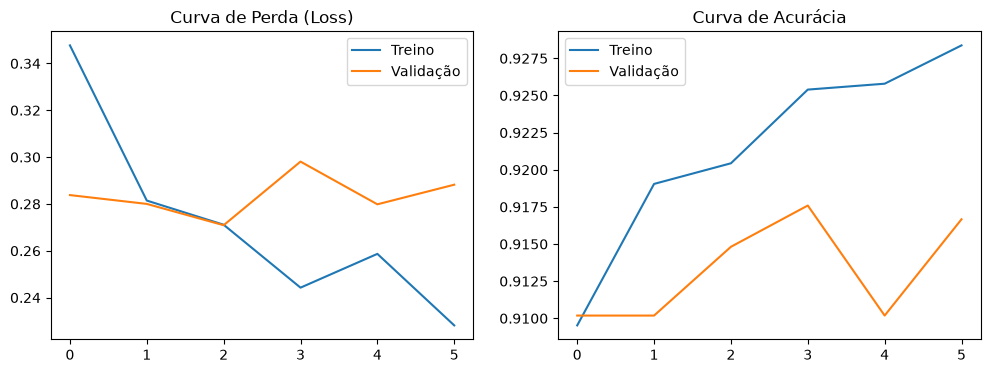

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step

 MATRIZ DE CONFUSÃO:
[[457  83]
 [ 18 522]]

 RELATÓRIO DE MÉTRICAS (Acurácia, Precisão, Recall, F1):
              precision    recall  f1-score   support

        True       0.96      0.85      0.90       540
        Fake       0.86      0.97      0.91       540

    accuracy                           0.91      1080
   macro avg       0.91      0.91      0.91      1080
weighted avg       0.91      0.91      0.91      1080



In [17]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Curva de Perda (Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Curva de Acurácia')
plt.legend()
plt.show()

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("\n MATRIZ DE CONFUSÃO:")
print(confusion_matrix(y_test, y_pred))

print("\n RELATÓRIO DE MÉTRICAS (Acurácia, Precisão, Recall, F1):")
print(classification_report(y_test, y_pred, target_names=['True', 'Fake']))